Setup and Data Loading

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the raw data
df = pd.read_csv('house prediction.csv', header=None)

# 2. Convert text to numbers (Encoding)
# This handles the text columns so the model doesn't crash
df = pd.get_dummies(df, drop_first=True)

# 3. FIX: Assign names to ALL columns
# This ensures we don't lose the feature columns
df.columns = [f'Feature_{i}' for i in range(len(df.columns) - 1)] + ['Price']

print(f"Success! Total columns now: {len(df.columns)}")
print(f"Columns: {df.columns.tolist()[:5]} ... {df.columns.tolist()[-1:]}")

# 4. Define X (Features) and y (Target)
X = df.drop('Price', axis=1)
y = df['Price']

# 5. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")

Success! Total columns now: 505
Columns: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4'] ... ['Price']
Training set: 404 samples, 504 features


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make Predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate Metrics
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("--- Linear Regression Results ---")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"R-squared Score: {r2_lr:.4f}")

--- Linear Regression Results ---
Mean Squared Error (MSE): 1.00
R-squared Score: 0.0000


In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Initialize models
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train and print results
models = {"Decision Tree": dt_model, "Random Forest": rf_model}

print("--- Model Comparison ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name}: MSE = {mse:.2f}, R2 = {r2:.4f}")

--- Model Comparison ---
Decision Tree: MSE = 1.00, R2 = 0.0000
Random Forest: MSE = 0.32, R2 = 0.0000


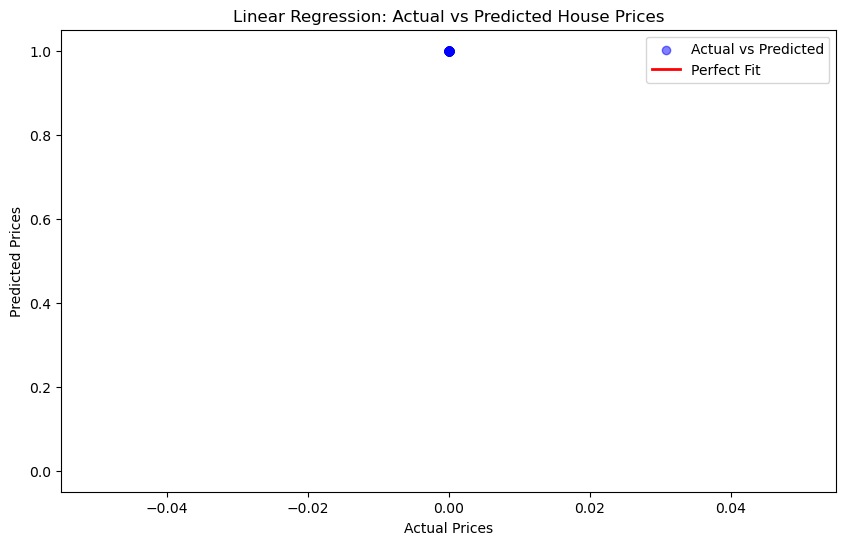

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, color='blue', alpha=0.5, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, label='Perfect Fit')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Linear Regression: Actual vs Predicted House Prices')
plt.legend()
plt.show()